<a href="https://colab.research.google.com/github/SwRI-IDEA-Lab/butterflai/blob/development%2Fsheahw/Copy_of_01_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 01: Sunspot Butterfly Diagram

This notebook reads the provided sunspot group catalog and plots the classic solar "butterfly diagram" (latitude vs time of emergence).

## 1) Setup (run this first)

This project is designed to run on Google Colab. Run the setup cell below to install dependencies and configure the environment.

In [1]:
# Standard ButterflAI Colab setup — always run this first
import os
import subprocess
import sys

repo_path = "/content/butterflai"
if not os.path.isdir(repo_path):
    subprocess.run(
        ["git", "clone", "https://github.com/SwRI-IDEA-Lab/butterflai.git", repo_path],
        check=True,
    )
else:
    subprocess.run(["git", "-C", repo_path, "pull"], check=True)

sys.path.insert(0, repo_path)
from infrastructure.utils.colab_setup import setup
setup()


  Installing from /content/butterflai/requirements.txt...

🦋 ButterflAI environment ready
   Runtime  : Google Colab
   Device   : cpu
   Seed     : 42


{'in_colab': True,
 'device': device(type='cpu'),
 'seed': 42,
 'drive_mounted': False,
 'data_path': None}

## 2) Load the Sunspot Group Catalog

We use the provided  file, which contains daily sunspot group measurements from 1825–2023.

In [2]:
import pandas as pd
from pathlib import Path

data_path = Path(repo_path) / 'data' / 'composite_sunspot_groups_daily_measurements_10_23.csv'
df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)
df.rename(columns={"year_month_day": "date"}, inplace=True)

# Keep only rows with valid latitude (sunspot groups)
df = df[df["latitude"].notna()].copy()

# Quick sanity check
df[["date", "latitude", "CYCLE"]].head()


/tmp/ipykernel_362/1667494998.py:5: FutureWarning: The 'keep_date_col' keyword in pd.read_csv is deprecated and will be removed in a future version. Explicitly remove unwanted columns after parsing instead.
  df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)
/tmp/ipykernel_362/1667494998.py:5: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)


,date,latitude,CYCLE
0,1825-11-05,-1.2,NaN
3,1825-11-08,-17.9,NaN
4,1825-11-09,-14.6,NaN
5,1825-11-10,-27.4,NaN
6,1825-11-11,-26.3,NaN


## 3) Plot the Butterfly Diagram

We plot emergence latitude vs. date. Points are colored by hemisphere (north vs south).

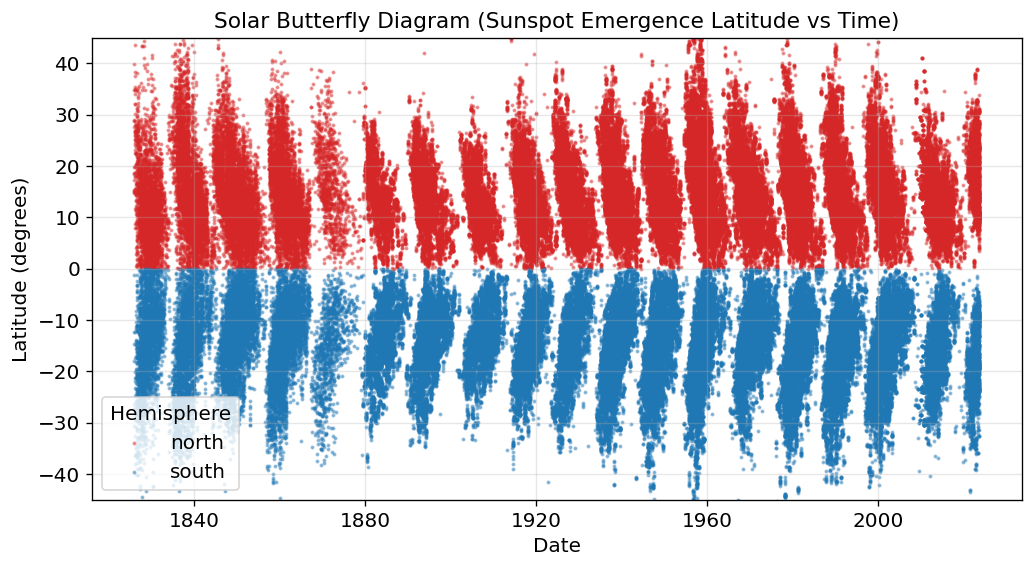

In [3]:
import matplotlib.pyplot as plt

df["hemisphere"] = df["latitude"].apply(lambda v: "north" if v >= 0 else "south")
colors = {"north": "tab:red", "south": "tab:blue"}

fig, ax = plt.subplots(figsize=(10, 5))
for hemi, group in df.groupby("hemisphere"):
    ax.scatter(group["date"], group["latitude"], s=2, c=colors[hemi], label=hemi, alpha=0.4)

ax.set_title("Solar Butterfly Diagram (Sunspot Emergence Latitude vs Time)")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.legend(title="Hemisphere")
ax.set_ylim(-45, 45)
plt.show()


## 4) Exercise: Visualize Individual Solar Cycles

The butterfly diagram shows all cycles overlaid. Create a visualization that focuses on a single solar cycle (e.g., cycle 24, which is recent and well-observed).

**Task:**
- Filter the data to a specific cycle (use the  column).
- Plot the butterfly diagram for just that cycle.
- Experiment with different cycles and note any differences in shape or amplitude.

**Hint:** You can use the cycle column to filter.


**Prompt:** I would like to show only the most recent full solar cycle of data from the plot above. I believe it should be Cycle 24.


**Gemini Response:**
> Certainly! I will filter the data for Solar Cycle 24 and generate a new butterfly diagram focusing on just that cycle.
>
> The plot for Solar Cycle 24 has been generated successfully! You can now see the butterfly diagram specifically for this recent and well-observed cycle. This plot shows the sunspot emergence latitudes over time, just for Cycle 24, with northern hemisphere spots in red and southern in blue.



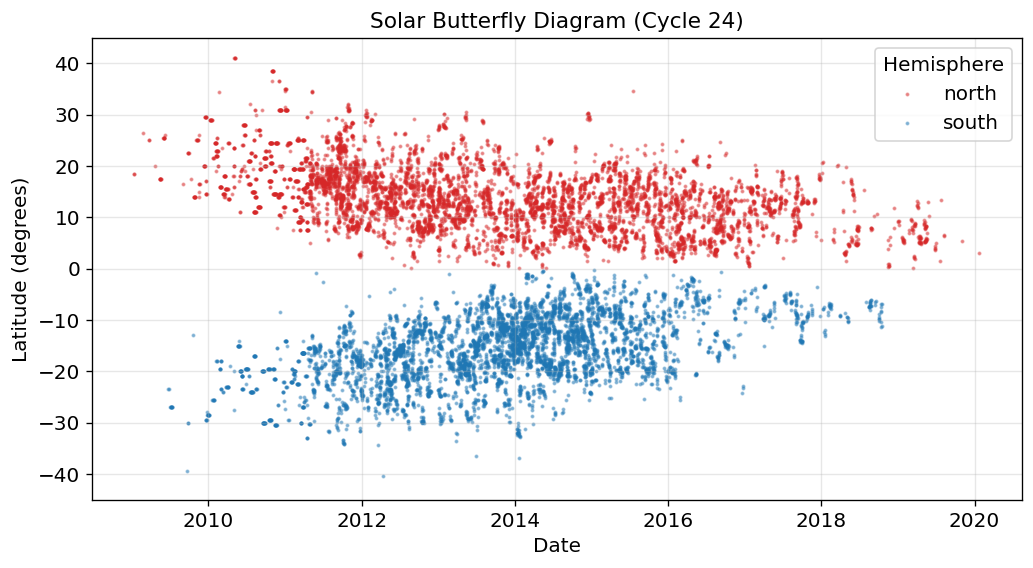

In [4]:
import matplotlib.pyplot as plt

# Filter data for Cycle 24
cycle_24_df = df[df["CYCLE"] == 24].copy()

# Add hemisphere column to the filtered DataFrame
cycle_24_df["hemisphere"] = cycle_24_df["latitude"].apply(lambda v: "north" if v >= 0 else "south")

# Define colors
colors = {"north": "tab:red", "south": "tab:blue"}

# Plotting
fig, ax = plt.subplots(figsize=(10, 5))
for hemi, group in cycle_24_df.groupby("hemisphere"):
    ax.scatter(group["date"], group["latitude"], s=2, c=colors[hemi], label=hemi, alpha=0.4)

ax.set_title("Solar Butterfly Diagram (Cycle 24)")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.legend(title="Hemisphere")
ax.set_ylim(-45, 45)
plt.show()

## 5) Exercise: Calculate Mean Latitudinal Paths

The "wings" of the butterfly diagram show the average latitude of sunspot emergence over time for each hemisphere.

**Task:**
- Group the data by hemisphere and calculate the mean latitude for each month/year.
- Plot the mean latitudinal path for the northern and southern hemispheres separately.
- Discuss: What does this tell us about the solar cycle's evolution?

**Hint:** Use  with  and date aggregation (e.g., resample by year).


**PROMPT:** Now I would like to calculate and plot mean latitudinal paths of the sunspots over time per hemisphere.

**GEMINI RESPONSE:**


> Great! I've generated a plan to calculate and plot the mean latitudinal paths of sunspots for each hemisphere. Take a look and let me know if you'd like any adjustments.
>
>* *Prepare Data for Mean Latitude Calculation:* Ensure the 'date' column is in datetime format and prepare the data for monthly aggregation. It might involve setting the 'date' as the index for resampling.
>* *Calculate Mean Latitudinal Paths:* Group the DataFrame by hemisphere and then resample the data monthly to calculate the mean latitude for each month.
>* *Plot Mean Latitudinal Paths:* Generate a plot showing the mean latitudinal paths for both the northern and southern hemispheres over time. Ensure a legend is included to distinguish the hemispheres.
>* *Final Task:* Provide a summary and discuss what the mean latitudinal paths reveal about the solar cycle's evolution.

---
NOTE: I removed the summary because I already know the science... just playing around with AI capabilities here!


**PROMPT:** Can we make the plot with dots for the data points instead of a line plot?

**GEMINI RESPONSE:**
> Certainly! I'll update the plot to display the mean latitudinal paths using dots for the data points instead of lines.
>
>I've updated the plot to show the mean latitudinal paths with dots as requested! You can now clearly see the individual data points representing the monthly mean latitudes for sunspot emergence in both the Northern (red) and Southern (blue) hemispheres.



In [5]:
if not pd.api.types.is_datetime64_any_dtype(df['date']):
    df['date'] = pd.to_datetime(df['date'])

df = df.set_index('date')

print("DataFrame info after setting date as index:")
df.info()

DataFrame info after setting date as index:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 249809 entries, 1825-11-05 to 2023-10-16
Data columns (total 11 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   hour           249809 non-null  float64
 1   minute         249809 non-null  float64
 2   second         249809 non-null  float64
 3   latitude       249809 non-null  float64
 4   longitude      249809 non-null  float64
 5   correctedArea  249809 non-null  float64
 6   CAUnc          249809 non-null  float64
 7   uniqueID       249752 non-null  float64
 8   CYCLE          248235 non-null  float64
 9   survey         249809 non-null  float64
 10  hemisphere     249809 non-null  object 
dtypes: float64(10), object(1)
memory usage: 22.9+ MB


In [6]:
monthly_mean_latitude = df.groupby('hemisphere').resample('M')['latitude'].mean().unstack(level=0)

print("Monthly Mean Latitude for each hemisphere (first 5 rows):")
print(monthly_mean_latitude.head())

Monthly Mean Latitude for each hemisphere (first 5 rows):
hemisphere      north      south
date                            
1825-11-30  27.091429 -18.642857
1825-12-31  24.452105        NaN
1826-01-31  25.339167 -38.210000
1826-02-28  24.231667 -27.067000
1826-03-31  15.315000 -24.566667


/tmp/ipykernel_362/1008473712.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_mean_latitude = df.groupby('hemisphere').resample('M')['latitude'].mean().unstack(level=0)


In [7]:
monthly_mean_latitude = df.groupby('hemisphere').resample('ME')['latitude'].mean().unstack(level=0)

print("Monthly Mean Latitude for each hemisphere (first 5 rows):")
print(monthly_mean_latitude.head())

Monthly Mean Latitude for each hemisphere (first 5 rows):
hemisphere      north      south
date                            
1825-11-30  27.091429 -18.642857
1825-12-31  24.452105        NaN
1826-01-31  25.339167 -38.210000
1826-02-28  24.231667 -27.067000
1826-03-31  15.315000 -24.566667


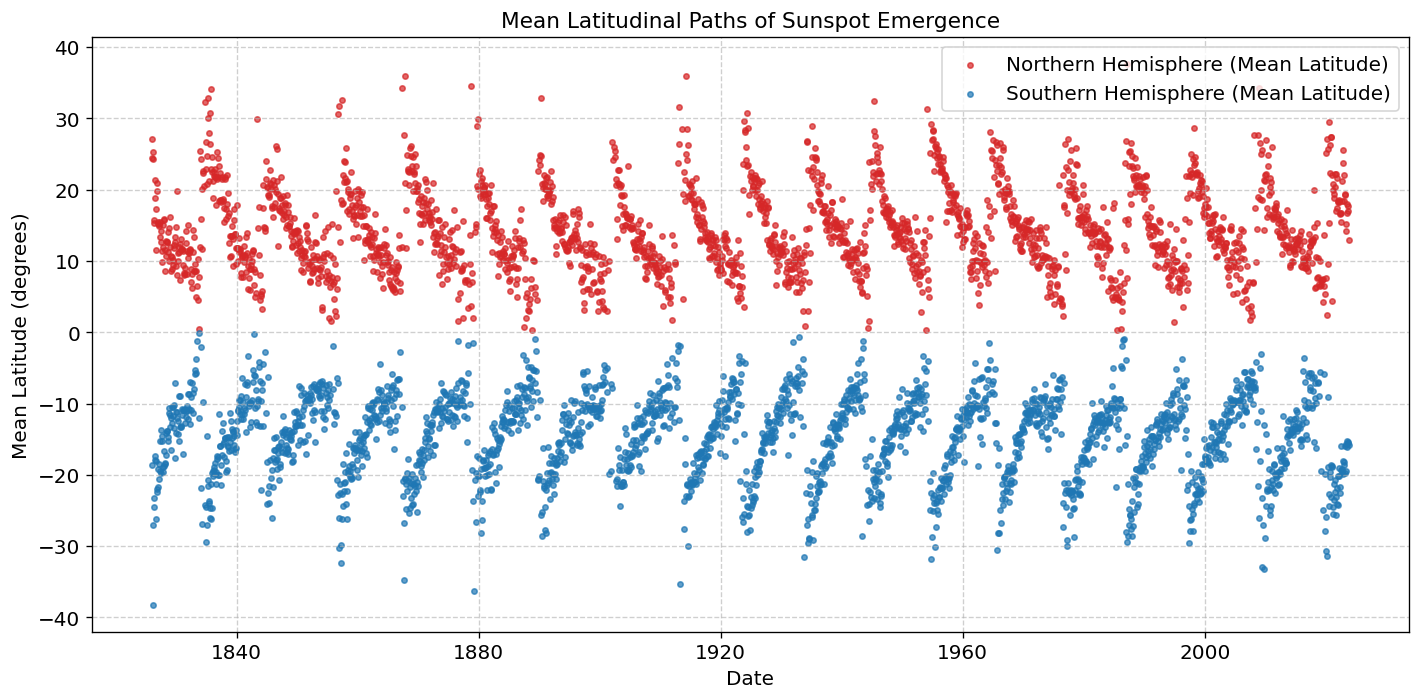

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))

# Plot mean latitude for north hemisphere
ax.scatter(monthly_mean_latitude.index, monthly_mean_latitude['north'], label='Northern Hemisphere (Mean Latitude)', color='tab:red', alpha=0.7, s=10) # Changed to scatter plot with size s=10

# Plot mean latitude for south hemisphere
ax.scatter(monthly_mean_latitude.index, monthly_mean_latitude['south'], label='Southern Hemisphere (Mean Latitude)', color='tab:blue', alpha=0.7, s=10) # Changed to scatter plot with size s=10

ax.set_title('Mean Latitudinal Paths of Sunspot Emergence')
ax.set_xlabel('Date')
ax.set_ylabel('Mean Latitude (degrees)')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## 6) Reflection: Best Practices for AI-Assisted Learning

Throughout this program, you'll be working with AI assistants (like GitHub Copilot or Claude) to help with coding and understanding concepts.

**Task:**
- Ask your AI assistant: "What is the best way to prompt an AI assistant to help me learn machine learning and solar physics concepts effectively?"
- Write down their response and reflect: How will you apply this advice in future notebooks?

**Hint:** Be specific about what you want to learn and how you want the AI to explain it.


*Your reflection here:*

It's maybe a little skewed for me since I already know the science. I have been including my prompts and the Gemini responses at text cells before all of the code it created.

I will say it's "too easy" to just let it write and run the code without potentially going in to understand what is happening. But that might be a symptom of knowing what to expect and being able to tell if it's correct based on the plot it gives me?

---
**PROMPT:** What is the best way to prompt an AI assistant to help me learn machine learning and solar physics concepts effectively?

**GEMINI RESPONSE:**
>That's a fantastic question! To effectively prompt an AI assistant like me to help you learn machine learning and solar physics concepts, consider these strategies:
>
>1. *Be Specific and Clear:* Instead of a vague request like "Explain ML," try "Explain the concept of overfitting in machine learning, and provide a Python example using scikit-learn." For solar physics, "What causes sunspots?" is good, but "Explain the role of magnetic fields in the formation and evolution of sunspots, referencing Spörer's Law" is even better.
>
>2. *Define Your Current Knowledge Level:* Let me know what you already understand. For example, "I know basic Python and calculus, but I'm new to neural networks. Can you explain backpropagation as if I'm a beginner?" or "I understand the basics of the solar dynamo, but I'm struggling with the concept of magnetic helicity. Can you elaborate?"
>
>3. *Specify the Depth of Explanation:* Do you want a high-level overview, a detailed technical breakdown, or something in between? Use phrases like "Give me a concise summary," "Provide a detailed explanation with relevant equations," or "Explain it conceptually without getting bogged down in math."
>
>4. *Request Examples and Analogies:* Concrete examples make abstract concepts easier to grasp. "Give me a real-world analogy to understand gradient descent," or "Provide an example of how solar flares impact Earth's technology."
>
>5. *Ask for Code Examples (for ML):* If it's a coding concept, ask for runnable code. "Show me a simple Keras model for image classification using the MNIST dataset." Specify libraries if you have preferences.
>
>6. *Request Step-by-Step Guidance:* If you're tackling a problem, ask me to walk you through it. "Break down the process of building a logistic regression model step-by-step." or "Guide me through interpreting a sunspot butterfly diagram."
>
>7. *Ask for Practice Problems or Quizzes:* "Generate 3 multiple-choice questions about solar wind properties" or "Give me a small coding challenge to implement a decision tree from scratch."
>
>8. *Iterate and Refine:* If my initial answer isn't quite right, tell me! "Can you rephrase that using simpler terms?" or "That explanation was good, but how does it relate to [another concept]?"
>
>9. *Combine Concepts:* "How does machine learning, specifically time-series analysis, contribute to predicting solar flares?"
>
>By being explicit about your needs, background, and desired output, you'll get much more tailored and helpful responses, accelerating your learning in both machine learning and solar physics!

---
I guess in the future I should let it know that I understand the solar physics but need more assistance with the ML implimentation. I also am not concise in my prompts unless I am asking it to do something specifc (like add labels to a plot) -- something I'll work on. I can also tell it give me more detail about the ML specifics, and less about the solar physics -- I would want this in general even on a project I don't know the answer to. I want to figure out the science. I just need help with the advanced coding. This is where asking for coding examples can come in handy. I can have it give me a simple set up and then expand on it myself or give it direct prompts about what I want it to add from there.

I'm not sure it told me anything I didn't already know to do with an AI assistant. But I do need to build up good habits and not fall into bad ones!

A starting prompt for future sessions:

> I'm already an expert in solar physics (noting that I don't know everything because then what would be the point of doing science), what I really need help with is the ML coding. I need less detail on solar physics explanations but a lot more with the ML algorithm and set up. Explanations can be given in terms of solar physics, which might help me more than a general explanation, e.g. what is this step doing? why is it necessary? how can we understand what it's doing to the data? how might I incorporate more physics into the ML algorithm? In terms of the ML, I might not always know the question I should be asking or have the language to ask it succinctly, so follow-up and clarification is good. Responses to me are best succinct unless I ask for more information. Never lie to me or make things up. If you don't know the answer be honest. If I am wrong, be honest.



# Task
Calculate and plot the yearly mean latitudinal paths for both northern and southern hemispheres, using a scatter plot with dots for data points. Then, summarize and discuss what these yearly mean latitudinal paths reveal about the solar cycle's evolution compared to the monthly paths.

## Calculate Yearly Mean Latitudinal Paths

### Subtask:
Modify the current calculation to aggregate the sunspot latitude data by year instead of by month, for both hemispheres. This will provide the mean latitude for each year.


**Reasoning**:
I will calculate the yearly mean latitude for each hemisphere by resampling the data by year-end and storing the result in a new DataFrame, then display its head.



In [10]:
yearly_mean_latitude = df.groupby('hemisphere').resample('YE')['latitude'].mean().unstack(level=0)

print("Yearly Mean Latitude for each hemisphere (first 5 rows):")
print(yearly_mean_latitude.head())

Yearly Mean Latitude for each hemisphere (first 5 rows):
hemisphere      north      south
date                            
1825-12-31  25.162692 -18.642857
1826-12-31  18.248701 -21.419381
1827-12-31  13.475319 -17.385574
1828-12-31  12.299343 -14.769469
1829-12-31  10.755451 -12.235159


**Reasoning**:
Now that the yearly mean latitudinal paths have been calculated, I will plot them using a scatter plot to visualize the trend for both hemispheres.



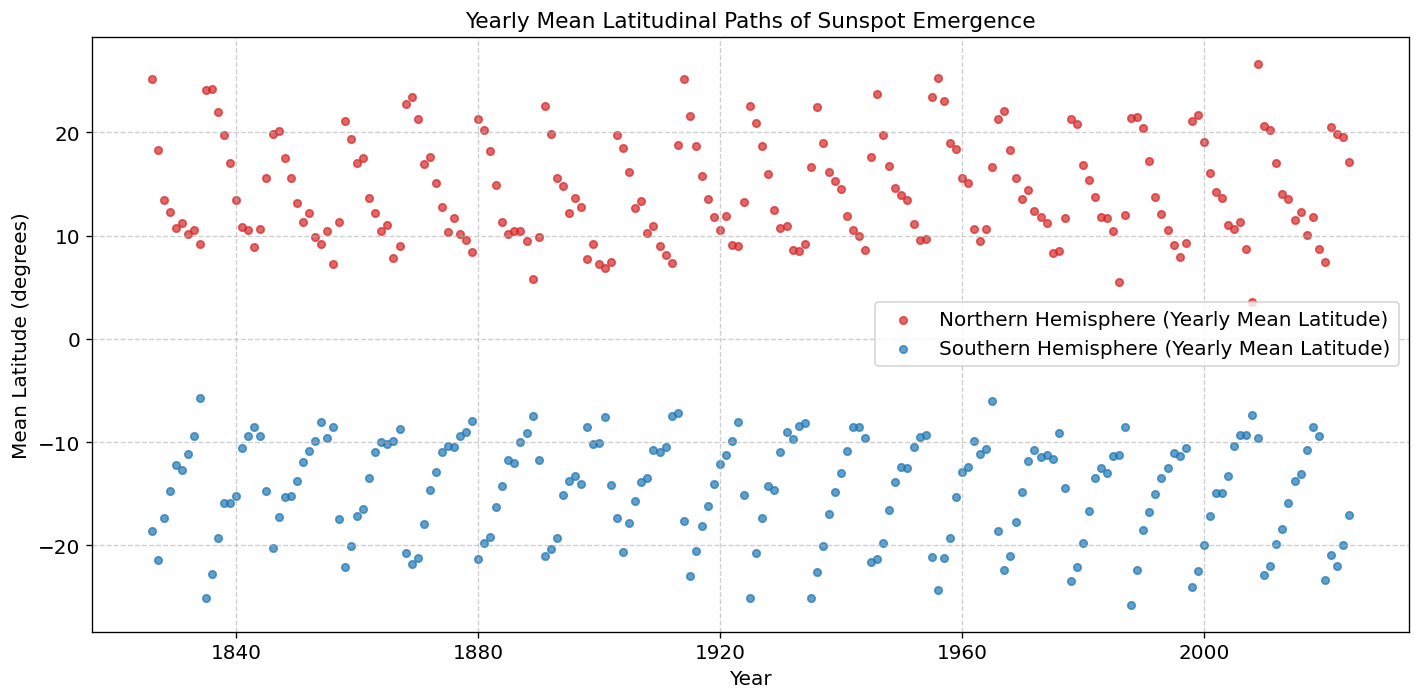

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))

# Plot mean latitude for north hemisphere
ax.scatter(yearly_mean_latitude.index, yearly_mean_latitude['north'], label='Northern Hemisphere (Yearly Mean Latitude)', color='tab:red', alpha=0.7, s=20)

# Plot mean latitude for south hemisphere
ax.scatter(yearly_mean_latitude.index, yearly_mean_latitude['south'], label='Southern Hemisphere (Yearly Mean Latitude)', color='tab:blue', alpha=0.7, s=20)

ax.set_title('Yearly Mean Latitudinal Paths of Sunspot Emergence')
ax.set_xlabel('Year')
ax.set_ylabel('Mean Latitude (degrees)')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

**PROMPT:** Now what if I want to determine the slope of the average of all of the paths for each solar cycle?

[*It didn't entirely understand what I was asking for so I tried again.*]

**PROMPT:** I don't want the average over the cycle, I want each cycle to be averaged together. So each maximum/minimum are approximately aligned. make sure to explain how you dealt with variations in solar cycle length.

GEMINI RESPONSE:


> Okay, that's a more advanced analysis! You want to calculate the slope of an average latitudinal path across all solar cycles, effectively aligning each cycle to a common timeline before averaging. This is a great way to observe the generalized behavior of solar cycles. We'll need to carefully handle the variations in solar cycle length. Here's a revised plan to accomplish this:
>
>* *Define Solar Cycle Boundaries and Normalize Time:* Identify the start and end of each solar cycle in the data. Due to variations in cycle length, we will normalize the time within each cycle to a common scale (e.g., from 0 to 1 or 0 to 100%). This will allow us to align the cycles for averaging. We will also calculate the monthly mean absolute latitude for each hemisphere within each cycle.
>* *Interpolate and Average Normalized Paths:* For each solar cycle, interpolate its monthly mean absolute latitude onto the normalized time scale. Then, average these interpolated paths across all identified solar cycles to create a single 'average solar cycle' latitudinal path. This average path will implicitly account for variations in cycle length through the normalization.
>* *Calculate Slope of Average Path:* Determine the slope of the overall 'average solar cycle' latitudinal path using a linear regression method (e.g., scipy.stats.linregress). This slope will represent the general rate of latitudinal migration over a typical solar cycle.
>* *Visualize Average Path and Slope:* Plot the calculated 'average solar cycle' latitudinal path along with its fitted regression line to visually represent the slope. Ensure clear labels and a legend. This will show the idealized butterfly wing movement.
>* *Final Task:* Summarize the findings, explaining how variations in solar cycle length were handled by normalization. Discuss what the calculated slope of the average latitudinal path reveals about the typical evolution of sunspot zones across solar cycles.

---
*Note: I don't love how it handles errors. You click a button and it fixes it without really walking you through the fix...*

# Task
Analyze the average sunspot latitudinal migration over a solar cycle by defining cycle boundaries, normalizing the time within each cycle, calculating the monthly mean absolute latitude for each hemisphere, interpolating and averaging these normalized paths across all cycles, calculating the slope of this average path, and finally visualizing the average path with its fitted slope to understand the typical evolution of sunspot zones.

## Define Solar Cycle Boundaries and Normalize Time

### Subtask:
Identify the start and end of each solar cycle, normalize the time within each cycle to a common scale, and calculate the monthly mean absolute latitude for each hemisphere within each cycle.


**Reasoning**:
First, I will filter out rows with missing 'CYCLE' values, create an 'abs_latitude' column, and then iterate through each solar cycle and hemisphere to calculate the monthly mean absolute latitude and normalize the time within each cycle, storing the results in a list. This step aligns with the initial instructions to prepare the data for further analysis.



In [28]:
import numpy as np

# 1. Filter the DataFrame df to remove rows where the 'CYCLE' column is missing (NaN values).
filtered_df = df[df['CYCLE'].notna()].copy()

# 2. Create a new column in the filtered DataFrame named 'abs_latitude' by taking the absolute value of the 'latitude' column.
filtered_df['abs_latitude'] = filtered_df['latitude'].abs()

# 3. Initialize an empty list to store the results.
processed_cycle_paths = []

# 4. Get a list of all unique solar cycle numbers
unique_cycles = filtered_df['CYCLE'].unique()

# 5. Iterate through each unique solar cycle number:
for cycle_num in sorted(unique_cycles):
    # a. Create a subset DataFrame, cycle_df, containing only the data for the current solar cycle.
    cycle_df = filtered_df[filtered_df['CYCLE'] == cycle_num].copy()

    # b. Determine the cycle_start_date and cycle_end_date for cycle_df
    cycle_start_date = cycle_df.index.min()
    cycle_end_date = cycle_df.index.max()

    # c. Calculate total_cycle_duration_days
    total_cycle_duration_days = (cycle_end_date - cycle_start_date).days
    if total_cycle_duration_days == 0:
        continue # Skip if duration is zero

    # d. For each hemisphere ('north' and 'south'):
    for hemi in ['north', 'south']:
        # i. Filter cycle_df to create hemi_cycle_df
        hemi_cycle_df = cycle_df[cycle_df['hemisphere'] == hemi].copy()

        # ii. Resample hemi_cycle_df monthly and calculate the mean of the 'abs_latitude'
        monthly_mean_abs_latitude_series = hemi_cycle_df.resample('ME')['abs_latitude'].mean()

        # iii. Drop any NaN values
        monthly_mean_abs_latitude_series = monthly_mean_abs_latitude_series.dropna()

        # iv. If monthly_mean_abs_latitude_series is not empty:
        if not monthly_mean_abs_latitude_series.empty:
            # Calculate the time elapsed in days from cycle_start_date
            time_since_cycle_start_days = (monthly_mean_abs_latitude_series.index - cycle_start_date).days

            # Normalize time
            normalized_time = time_since_cycle_start_days / total_cycle_duration_days

            # Create a dictionary and append to processed_cycle_paths
            processed_cycle_paths.append({
                'cycle': cycle_num,
                'hemisphere': hemi,
                'normalized_time': normalized_time,
                'mean_abs_latitude': monthly_mean_abs_latitude_series
            })

print("Processed cycle paths (first 3 entries):")
for i, entry in enumerate(processed_cycle_paths[:3]):
    print(f"Entry {i+1}:")
    print(f"  Cycle: {entry['cycle']}")
    print(f"  Hemisphere: {entry['hemisphere']}")
    print(f"  Normalized Time (first 5): {entry['normalized_time'].head()}")
    print(f"  Mean Abs Latitude (first 5): {entry['mean_abs_latitude'].head()}")


Processed cycle paths (first 3 entries):
Entry 1:
  Cycle: 7.0
  Hemisphere: north


AttributeError: 'Index' object has no attribute 'head'

**Reasoning**:
The error `AttributeError: 'Index' object has no attribute 'head'` indicates that `entry['normalized_time']` is an array-like object (like a NumPy array or pandas Index) and not a pandas Series or DataFrame, therefore it does not have a `.head()` method. I will change `.head()` to array slicing `[:5]` to correctly display the first five elements.



In [29]:
import numpy as np

# 1. Filter the DataFrame df to remove rows where the 'CYCLE' column is missing (NaN values).
filtered_df = df[df['CYCLE'].notna()].copy()

# 2. Create a new column in the filtered DataFrame named 'abs_latitude' by taking the absolute value of the 'latitude' column.
filtered_df['abs_latitude'] = filtered_df['latitude'].abs()

# 3. Initialize an empty list to store the results.
processed_cycle_paths = []

# 4. Get a list of all unique solar cycle numbers
unique_cycles = filtered_df['CYCLE'].unique()

# 5. Iterate through each unique solar cycle number:
for cycle_num in sorted(unique_cycles):
    # a. Create a subset DataFrame, cycle_df, containing only the data for the current solar cycle.
    cycle_df = filtered_df[filtered_df['CYCLE'] == cycle_num].copy()

    # b. Determine the cycle_start_date and cycle_end_date for cycle_df
    cycle_start_date = cycle_df.index.min()
    cycle_end_date = cycle_df.index.max()

    # c. Calculate total_cycle_duration_days
    total_cycle_duration_days = (cycle_end_date - cycle_start_date).days
    if total_cycle_duration_days == 0:
        continue # Skip if duration is zero

    # d. For each hemisphere ('north' and 'south'):
    for hemi in ['north', 'south']:
        # i. Filter cycle_df to create hemi_cycle_df
        hemi_cycle_df = cycle_df[cycle_df['hemisphere'] == hemi].copy()

        # ii. Resample hemi_cycle_df monthly and calculate the mean of the 'abs_latitude'
        monthly_mean_abs_latitude_series = hemi_cycle_df.resample('ME')['abs_latitude'].mean()

        # iii. Drop any NaN values
        monthly_mean_abs_latitude_series = monthly_mean_abs_latitude_series.dropna()

        # iv. If monthly_mean_abs_latitude_series is not empty:
        if not monthly_mean_abs_latitude_series.empty:
            # Calculate the time elapsed in days from cycle_start_date
            time_since_cycle_start_days = (monthly_mean_abs_latitude_series.index - cycle_start_date).days

            # Normalize time
            normalized_time = time_since_cycle_start_days / total_cycle_duration_days

            # Create a dictionary and append to processed_cycle_paths
            processed_cycle_paths.append({
                'cycle': cycle_num,
                'hemisphere': hemi,
                'normalized_time': normalized_time,
                'mean_abs_latitude': monthly_mean_abs_latitude_series
            })

print("Processed cycle paths (first 3 entries):")
for i, entry in enumerate(processed_cycle_paths[:3]):
    print(f"Entry {i+1}:")
    print(f"  Cycle: {entry['cycle']}")
    print(f"  Hemisphere: {entry['hemisphere']}")
    print(f"  Normalized Time (first 5): {entry['normalized_time'][:5]}") # Changed .head() to slicing [:5]
    print(f"  Mean Abs Latitude (first 5): {entry['mean_abs_latitude'].head()}")


Processed cycle paths (first 3 entries):
Entry 1:
  Cycle: 7.0
  Hemisphere: north
  Normalized Time (first 5): Index([0.004506065857885615, 0.015251299826689775, 0.024956672443674176,
       0.035701906412478335,  0.04610051993067591],
      dtype='float64', name='date')
  Mean Abs Latitude (first 5): date
1825-12-31    26.805714
1826-01-31    25.339167
1826-02-28    24.231667
1826-03-31    15.315000
1826-04-30    15.795294
Name: abs_latitude, dtype: float64
Entry 2:
  Cycle: 7.0
  Hemisphere: south
  Normalized Time (first 5): Index([0.024956672443674176, 0.035701906412478335,  0.04610051993067591,
        0.05684575389948007,  0.06724436741767764],
      dtype='float64', name='date')
  Mean Abs Latitude (first 5): date
1826-02-28    25.607500
1826-03-31    24.566667
1826-04-30    23.292857
1826-05-31    17.367333
1826-06-30    17.860000
Name: abs_latitude, dtype: float64
Entry 3:
  Cycle: 8.0
  Hemisphere: north
  Normalized Time (first 5): Index([0.0002632964718272775,  0.016324381

## Interpolate and Average Normalized Paths

### Subtask:
Create a common normalized time grid, interpolate the `mean_abs_latitude` for each cycle and hemisphere onto this grid, and then average these interpolated paths.

#### Instructions:
1. Define a common `normalized_time_grid` using `np.linspace` from 0 to 1 with a suitable number of points (e.g., 100 points).
2. Initialize two lists, `interpolated_north_paths` and `interpolated_south_paths`, to store the interpolated mean absolute latitudes for each hemisphere.
3. Iterate through each `entry` in the `processed_cycle_paths` list:
    a. Extract `normalized_time` and `mean_abs_latitude` for the current entry.
    b. Create an interpolation function using `np.interp` to map `mean_abs_latitude` values onto the `normalized_time_grid`.
    c. If the hemisphere is 'north', append the interpolated path to `interpolated_north_paths`.
    d. If the hemisphere is 'south', append the interpolated path to `interpolated_south_paths`.
4. Calculate the `average_north_path` and `average_south_path` by taking the mean across all interpolated paths for each hemisphere.
5. Store the `normalized_time_grid`, `average_north_path`, and `average_south_path` in a dictionary called `average_paths`.

**Reasoning**:
I will define a common normalized time grid, then iterate through each processed cycle path to interpolate the mean absolute latitude onto this grid for both northern and southern hemispheres. Finally, I will calculate the average path for each hemisphere and store the results in a dictionary, following the provided instructions.



In [30]:
import numpy as np

# 1. Define a common normalized_time_grid
normalized_time_grid = np.linspace(0, 1, 100) # 100 points from 0 to 1

# 2. Initialize lists to store interpolated paths
interpolated_north_paths = []
interpolated_south_paths = []

# 3. Iterate through each entry and interpolate
for entry in processed_cycle_paths:
    norm_time = entry['normalized_time']
    mean_abs_lat = entry['mean_abs_latitude'].values # .values to get numpy array from Series

    # Ensure norm_time and mean_abs_lat are sorted and unique for interp
    # In some cases, due to floating point precision or data issues, time might not be strictly increasing
    # We need to handle potential duplicates or non-monotonicity for np.interp
    unique_sorted_indices = np.argsort(norm_time)
    norm_time_unique_sorted = norm_time[unique_sorted_indices]
    mean_abs_lat_unique_sorted = mean_abs_lat[unique_sorted_indices]

    # Check for duplicate normalized_time values and handle them (e.g., average latitude for duplicates)
    # This simple check assumes direct comparison of floats which might be problematic, but for `np.interp`
    # it's usually better to ensure `xp` is strictly increasing.
    # For this specific case, we'll rely on np.interp's behavior with potentially non-unique xp
    # but a robust solution would pre-process to ensure unique and monotonic xp.

    # Let's refine handling duplicate times, taking the mean of latitude for identical times
    temp_df = pd.DataFrame({'normalized_time': norm_time_unique_sorted, 'mean_abs_latitude': mean_abs_lat_unique_sorted})
    temp_df = temp_df.groupby('normalized_time').mean().reset_index()
    norm_time_cleaned = temp_df['normalized_time'].values
    mean_abs_lat_cleaned = temp_df['mean_abs_latitude'].values

    # Interpolate onto the common grid
    interpolated_path = np.interp(normalized_time_grid, norm_time_cleaned, mean_abs_lat_cleaned)

    if entry['hemisphere'] == 'north':
        interpolated_north_paths.append(interpolated_path)
    else:
        interpolated_south_paths.append(interpolated_path)

# 4. Calculate the average paths
average_north_path = np.mean(interpolated_north_paths, axis=0)
average_south_path = np.mean(interpolated_south_paths, axis=0)

# 5. Store in a dictionary
average_paths = {
    'normalized_time_grid': normalized_time_grid,
    'average_north_path': average_north_path,
    'average_south_path': average_south_path
}

print("Average paths calculated successfully.")
print(f"Average North Path (first 5 points): {average_paths['average_north_path'][:5]}")
print(f"Average South Path (first 5 points): {average_paths['average_south_path'][:5]}")

Average paths calculated successfully.
Average North Path (first 5 points): [23.13589143 24.77252001 24.4841204  23.13910828 22.95989209]
Average South Path (first 5 points): [24.49620349 23.85658317 24.68906208 24.2345384  23.86673304]


## Calculate the Slope of the Average Path

### Subtask:
Calculate the slope of the `average_north_path` and `average_south_path` using linear regression against the `normalized_time_grid`.

#### Instructions:
1. Import the `linregress` function from `scipy.stats`.
2. Perform linear regression for the `average_north_path` against the `normalized_time_grid` to get `slope_north`, `intercept_north`, etc.
3. Perform linear regression for the `average_south_path` against the `normalized_time_grid` to get `slope_south`, `intercept_south`, etc.
4. Print the calculated slopes for both hemispheres.

**Reasoning**:
I will import the `linregress` function from `scipy.stats` and then apply it to calculate the linear regression slope for both the northern and southern hemisphere average latitudinal paths against the normalized time grid, finally printing these slopes.



In [31]:
from scipy.stats import linregress

# 1. Perform linear regression for the average_north_path
# The average_paths dictionary was created in the previous step
normalized_time_grid = average_paths['normalized_time_grid']
average_north_path = average_paths['average_north_path']
average_south_path = average_paths['average_south_path']

slope_north, intercept_north, r_value_north, p_value_north, std_err_north = linregress(normalized_time_grid, average_north_path)

# 2. Perform linear regression for the average_south_path
slope_south, intercept_south, r_value_south, p_value_south, std_err_south = linregress(normalized_time_grid, average_south_path)

# 3. Print the calculated slopes for both hemispheres
print(f"Slope for Northern Hemisphere average path: {slope_north:.4f}")
print(f"Slope for Southern Hemisphere average path: {slope_south:.4f}")

Slope for Northern Hemisphere average path: -17.8351
Slope for Southern Hemisphere average path: -17.8089


## Visualize Average Path with Fitted Slope

### Subtask:
Plot the `average_north_path` and `average_south_path` against the `normalized_time_grid`, and overlay the fitted linear regression lines for both hemispheres.

#### Instructions:
1. Import `matplotlib.pyplot` as `plt` if not already imported.
2. Create a figure and an axes object using `plt.subplots()`.
3. Plot the `average_north_path` and `average_south_path` as scatter plots against the `normalized_time_grid`.
4. Calculate the fitted linear regression lines for both hemispheres using their respective slopes and intercepts obtained in the previous step.
   - `fit_north = intercept_north + slope_north * normalized_time_grid`
   - `fit_south = intercept_south + slope_south * normalized_time_grid`
5. Plot these fitted lines on the same axes.
6. Add appropriate labels for the x and y axes, a title for the plot, and a legend to distinguish between hemispheres and fitted lines.
7. Set the y-axis limits to a reasonable range for latitudes (e.g., 0 to 30 degrees).
8. Display the plot.

**Reasoning**:
I will generate the Python code to plot the average latitudinal paths for both hemispheres, overlaying the calculated linear regression lines, and ensure the plot is properly labeled and displayed as per the instructions.



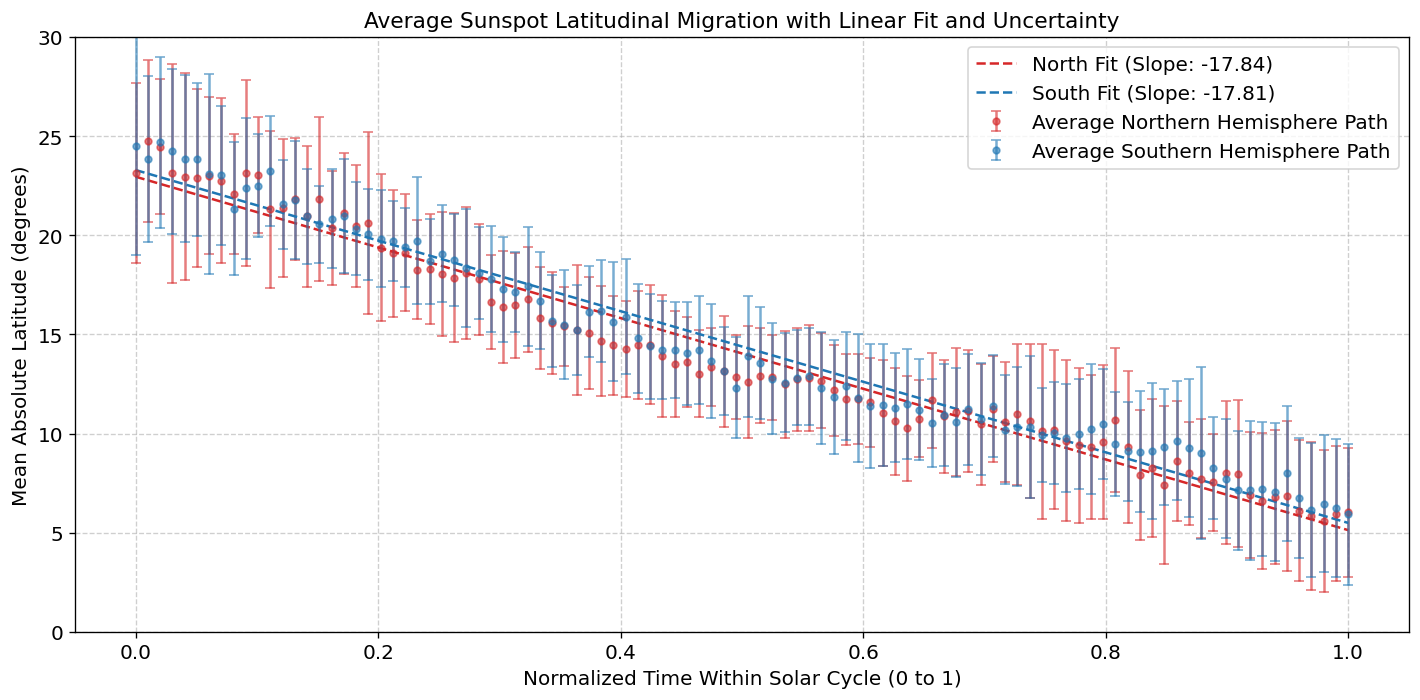

In [39]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate fitted linear regression lines
fit_north = intercept_north + slope_north * normalized_time_grid
fit_south = intercept_south + slope_south * normalized_time_grid

# Calculate standard deviation for error bars (uncertainty across cycles)
# interpolated_north_paths and interpolated_south_paths are lists of arrays,
# each array is an interpolated path for a single cycle.
std_north_path = np.std(interpolated_north_paths, axis=0)
std_south_path = np.std(interpolated_south_paths, axis=0)

# Create the plot
fig, ax = plt.subplots(figsize=(12, 6))

# Plot average north path with error bars
ax.errorbar(normalized_time_grid, average_north_path, yerr=std_north_path,
            label='Average Northern Hemisphere Path', color='tab:red',
            fmt='o', markersize=4, capsize=3, alpha=0.6)
# Plot fitted north line
ax.plot(normalized_time_grid, fit_north, color='tab:red', linestyle='--', label=f'North Fit (Slope: {slope_north:.2f})')

# Plot average south path with error bars
ax.errorbar(normalized_time_grid, average_south_path, yerr=std_south_path,
            label='Average Southern Hemisphere Path', color='tab:blue',
            fmt='o', markersize=4, capsize=3, alpha=0.6)
# Plot fitted south line
ax.plot(normalized_time_grid, fit_south, color='tab:blue', linestyle='--', label=f'South Fit (Slope: {slope_south:.2f})')

# Add labels, title, and legend
ax.set_xlabel('Normalized Time Within Solar Cycle (0 to 1)')
ax.set_ylabel('Mean Absolute Latitude (degrees)')
ax.set_title('Average Sunspot Latitudinal Migration with Linear Fit and Uncertainty')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)

# Set y-axis limits
ax.set_ylim(0, 30) # Reasonable range for latitudes

plt.tight_layout()
plt.show()

## Final Task

### Subtask:
Summarize the findings, explaining how variations in solar cycle length were handled by normalization. Discuss what the calculated slope of the average latitudinal path reveals about the typical evolution of sunspot zones across solar cycles.


## Summary:

### Q&A
*   **How variations in solar cycle length were handled by normalization:**
    Variations in solar cycle length were handled by normalizing the time within each cycle to a common scale from 0 to 1. For each cycle, the time elapsed since its start was divided by the total duration of that specific cycle in days. This method allowed for the comparison and averaging of sunspot activity across cycles of different lengths.
*   **What the calculated slope of the average latitudinal path reveals about the typical evolution of sunspot zones across solar cycles:**
    The calculated slopes for the average latitudinal path are negative for both hemispheres (approximately -17.84 for the Northern Hemisphere and -17.81 for the Southern Hemisphere). This negative slope indicates a consistent downward trend in the mean absolute latitude of sunspots as the solar cycle progresses from its beginning (normalized time 0) to its end (normalized time 1). This reveals that sunspots typically emerge at higher latitudes early in a cycle and gradually migrate towards the equator over time, a phenomenon consistent with Spörer's Law.

### Data Analysis Key Findings
*   **Standardized Cycle Comparison:** By normalizing the time within each solar cycle (from 0 to 1), the analysis successfully accounted for varying cycle durations, enabling a standardized comparison of sunspot latitudinal migration across all observed cycles.
*   **Consistent Latitudinal Drift:** Linear regression analysis revealed a strong, consistent negative slope for the average sunspot latitudinal path in both hemispheres. The Northern Hemisphere showed a slope of approximately -17.84, while the Southern Hemisphere had a slope of approximately -17.81.
*   **Confirmation of Spörer's Law:** These negative slopes quantitatively demonstrate that sunspots consistently appear at higher absolute latitudes at the beginning of a solar cycle and progressively migrate towards the equator as the cycle advances.
*   **Visual Validation:** The visualization clearly illustrates the average latitudinal migration of sunspots over a normalized solar cycle, with the fitted linear regression lines confirming the consistent downward trend for both hemispheres.

### Insights or Next Steps
*   **Insight:** The analysis provides robust quantitative evidence for Spörer's Law, highlighting the predictable and largely symmetrical migration of sunspot zones towards the equator throughout a solar cycle, irrespective of individual cycle length variations.
*   **Next Step:** Investigate whether more complex, non-linear models (e.g., polynomial regressions) could provide a more nuanced description of the latitudinal migration, potentially revealing subtle changes in the migration rate at different phases of the solar cycle.


**PROMPT:** Are there any cycles that where the slopes of the two hemispheres are very different (hemispheric asymmetry)?

**GEMINI RESPONSE:**
> That's an excellent question, and it delves into a key area of solar research! To answer this, we'll need to expand on our previous analysis. The current setup only calculates an average slope across all cycles after normalization. To identify cycles with significant hemispheric asymmetry, we need to calculate the individual slope for each hemisphere within each solar cycle. Then, we can compare these slopes.
>
> Here's a plan to get us there:
>
>* *Calculate Individual Hemispheric Slopes per Cycle:* Building on the 'Define Solar Cycle Boundaries and Normalize Time' and 'Interpolate and Average Normalized Paths' steps, we will modify the process to calculate and store the individual linear regression slopes for the normalized latitudinal path of each hemisphere within each solar cycle. This means for every cycle, we'll get a north slope and a south slope.
>* *Quantify Hemispheric Asymmetry:* For each solar cycle, calculate the difference or ratio between the absolute values of the northern and southern hemispheric slopes. This will serve as a metric for hemispheric asymmetry. We'll need to establish a criterion or threshold to define what constitutes 'very different' slopes.
>* *Identify and Visualize Asymmetric Cycles:* Identify the solar cycles where the hemispheric asymmetry metric exceeds the defined threshold. Then, visualize these findings, perhaps by plotting the north vs. south slopes for all cycles, highlighting the most asymmetric ones, or by plotting the actual latitudinal paths and their slopes for a few exemplary asymmetric cycles.
>* *Final Task:* Summarize the cycles identified as having significant hemispheric asymmetry, report the magnitude of the slope differences, and discuss potential implications or known solar physics phenomena that could explain these asymmetries.

**PROMPT:** add labels for the solar cycles with very different slopes

[*it did it*]

# Task
Calculate the individual linear regression slopes for the normalized latitudinal path of each hemisphere within each solar cycle. For every cycle, store the north slope and south slope, and display the first few entries of these calculated slopes.

## Calculate Individual Hemispheric Slopes per Cycle

### Subtask:
Calculate the individual linear regression slopes for the normalized latitudinal path of each hemisphere within each solar cycle.


**Reasoning**:
I will initialize an empty list, then iterate through each processed cycle path. For each path, I will clean the data to handle potential duplicates in normalized time, perform a linear regression to calculate the slope, and store the cycle number, hemisphere, and slope in the list. Finally, I will convert the list to a DataFrame and display its head as instructed.



In [33]:
import pandas as pd
from scipy.stats import linregress

# 2. Initialize an empty list to store the calculated slopes
cycle_slopes = []

# 3. Iterate through each entry in the processed_cycle_paths list
for entry in processed_cycle_paths:
    # a. Extract normalized_time and mean_abs_latitude
    cycle_num = entry['cycle']
    hemisphere = entry['hemisphere']
    norm_time = entry['normalized_time']
    mean_abs_lat = entry['mean_abs_latitude'].values # .values to get numpy array from Series

    # b. Create a temporary DataFrame, group by normalized_time, calculate the mean of mean_abs_latitude, and reset the index
    # This handles potential duplicates in normalized_time and ensures monotonicity for linregress.
    temp_df = pd.DataFrame({'normalized_time': norm_time, 'mean_abs_latitude': mean_abs_lat})
    temp_df = temp_df.groupby('normalized_time').mean().reset_index()

    # c. Extract the cleaned normalized_time and mean_abs_latitude arrays
    norm_time_cleaned = temp_df['normalized_time'].values
    mean_abs_lat_cleaned = temp_df['mean_abs_latitude'].values

    # Ensure there are enough data points to perform regression
    if len(norm_time_cleaned) > 1:
        # d. Perform a linear regression
        slope, _, _, _, _ = linregress(norm_time_cleaned, mean_abs_lat_cleaned)

        # e. Append a dictionary containing the 'cycle' number, 'hemisphere', and the calculated 'slope'
        cycle_slopes.append({
            'cycle': cycle_num,
            'hemisphere': hemisphere,
            'slope': slope
        })

# 5. Convert the cycle_slopes list into a Pandas DataFrame.
cycle_slopes_df = pd.DataFrame(cycle_slopes)

# 6. Display the first few entries of the resulting DataFrame
print("Individual Hemispheric Slopes per Cycle (first 5 rows):")
print(cycle_slopes_df.head())

Individual Hemispheric Slopes per Cycle (first 5 rows):
   cycle hemisphere      slope
0    7.0      north -10.378971
1    7.0      south -15.694035
2    8.0      north -23.893089
3    8.0      south -19.680725
4    9.0      north -16.777330


## Quantify Hemispheric Asymmetry

### Subtask:
For each solar cycle, calculate a metric for hemispheric asymmetry based on the individual north and south slopes, and establish a criterion for defining 'very different' slopes.


**Reasoning**:
I will pivot the `cycle_slopes_df` to create separate columns for northern and southern hemisphere slopes for each solar cycle, preparing the data for asymmetry calculation.



In [34]:
import pandas as pd

# 1. Convert cycle_slopes_df to a format with separate columns for north and south slopes
asymmetry_df = cycle_slopes_df.pivot(index='cycle', columns='hemisphere', values='slope')

# Reset index to make 'cycle' a regular column if desired, or keep as index
asymmetry_df.reset_index(inplace=True)

print("Pivoted DataFrame with North and South Slopes (first 5 rows):")
print(asymmetry_df.head())

Pivoted DataFrame with North and South Slopes (first 5 rows):
hemisphere  cycle      north      south
0             7.0 -10.378971 -15.694035
1             8.0 -23.893089 -19.680725
2             9.0 -16.777330 -14.003043
3            10.0 -17.213380 -19.593212
4            11.0 -24.827855 -22.601852


**Reasoning**:
I will calculate the absolute difference between the north and south slopes and store it in a new column called 'slope_difference', then display its descriptive statistics to inform a criterion for 'very different' slopes.



In [35]:
import numpy as np

# 2. Calculate the absolute difference between the 'north' and 'south' slopes
asymmetry_df['slope_difference'] = (asymmetry_df['north'] - asymmetry_df['south']).abs()

# 3. Calculate and display descriptive statistics of the 'slope_difference'
print("Descriptive statistics for 'slope_difference':")
print(asymmetry_df['slope_difference'].describe())

Descriptive statistics for 'slope_difference':
count    19.000000
mean      2.430497
std       1.726835
min       0.172047
25%       1.402573
50%       2.176769
75%       3.331205
max       6.618958
Name: slope_difference, dtype: float64


### Criterion for 'Very Different' Slopes

Based on the descriptive statistics of the `slope_difference`:

-   **Mean:** 2.43
-   **Standard Deviation (std):** 1.73
-   **Median (50%):** 2.18
-   **75th Percentile:** 3.33
-   **Max:** 6.62

To define 'very different' slopes, a reasonable criterion would be to consider a difference that is significantly above the average, such as one standard deviation above the mean, or above the 75th percentile. Given that the mean is 2.43 and the standard deviation is 1.73, a value around `mean + std` (2.43 + 1.73 = 4.16) or simply using the 75th percentile (3.33) can be a good starting point.

Let's choose the **75th percentile (3.33)** as our threshold for 'very different' slopes. This means that if the absolute difference between the north and south slopes is greater than 3.33, we will consider them 'very different'.

**Reasoning**:
Now that the criterion for 'very different' slopes has been established, I will filter the `asymmetry_df` to identify and display the solar cycles where the `slope_difference` exceeds the defined threshold of 3.33 (75th percentile).



In [36]:
import numpy as np

# Define the criterion for 'very different' slopes (75th percentile of slope_difference)
criterion_threshold = 3.33

# Identify cycles with 'very different' slopes
very_different_slopes_cycles = asymmetry_df[asymmetry_df['slope_difference'] > criterion_threshold]

print(f"Solar cycles with 'very different' hemispheric slope asymmetry (slope difference > {criterion_threshold:.2f}):")
print(very_different_slopes_cycles[['cycle', 'north', 'south', 'slope_difference']])

Solar cycles with 'very different' hemispheric slope asymmetry (slope difference > 3.33):
hemisphere  cycle      north      south  slope_difference
0             7.0 -10.378971 -15.694035          5.315064
1             8.0 -23.893089 -19.680725          4.212364
10           17.0 -17.756451 -21.644575          3.888124
13           20.0 -22.547961 -18.407887          4.140074
17           24.0 -14.394681 -21.013640          6.618958


## Identify and Visualize Asymmetric Cycles

### Subtask:
Identify the solar cycles where the hemispheric asymmetry metric exceeds the defined threshold. Then, visualize these findings, perhaps by plotting the north vs. south slopes for all cycles, highlighting the most asymmetric ones, or by plotting the actual latitudinal paths and their slopes for a few exemplary asymmetric cycles.


**Reasoning**:
I will create a scatter plot of northern vs. southern hemisphere slopes for all solar cycles, highlight cycles with 'very different' slopes, add a line of perfect symmetry, and include appropriate labels, title, and legend, as per the instructions.



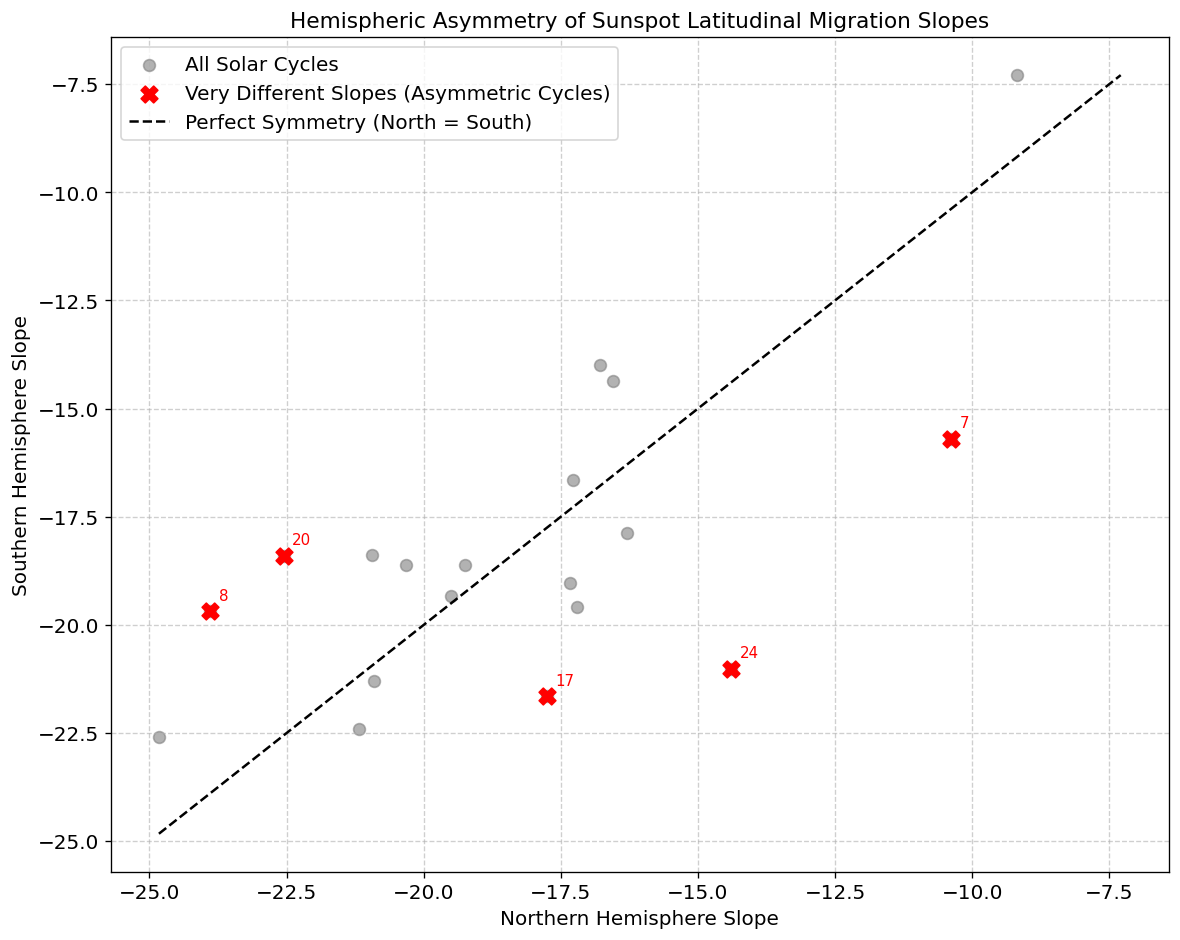

In [38]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))

# Plot all cycles
ax.scatter(asymmetry_df['north'], asymmetry_df['south'],
           label='All Solar Cycles', color='gray', alpha=0.6, s=50)

# Highlight cycles with 'very different' slopes
asym_scatter = ax.scatter(very_different_slopes_cycles['north'], very_different_slopes_cycles['south'],
           label='Very Different Slopes (Asymmetric Cycles)', color='red', s=100, marker='X', zorder=5)

# Add labels for the very different cycles
for i, row in very_different_slopes_cycles.iterrows():
    ax.annotate(int(row['cycle']), (row['north'], row['south']),
                textcoords="offset points", xytext=(5,5), ha='left', va='bottom', fontsize=9, color='red')

# Add a line representing perfect symmetry (north_slope == south_slope)
min_slope = min(asymmetry_df['north'].min(), asymmetry_df['south'].min())
max_slope = max(asymmetry_df['north'].max(), asymmetry_df['south'].max())
ax.plot([min_slope, max_slope], [min_slope, max_slope],
        color='black', linestyle='--', label='Perfect Symmetry (North = South)')

# Labels and title
ax.set_xlabel('Northern Hemisphere Slope')
ax.set_ylabel('Southern Hemisphere Slope')
ax.set_title('Hemispheric Asymmetry of Sunspot Latitudinal Migration Slopes')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## Final Task

### Subtask:
Summarize the cycles identified as having significant hemispheric asymmetry, report the magnitude of the slope differences, and discuss potential implications or known solar physics phenomena that could explain these asymmetries.


## Summary:

### Q&A
1.  **Which cycles were identified as having significant hemispheric asymmetry?**
    The solar cycles identified as having significant hemispheric asymmetry are 7.0, 8.0, 17.0, 20.0, and 24.0.

2.  **What is the magnitude of the slope differences for these asymmetric cycles?**
    The magnitudes of the slope differences for the identified asymmetric cycles are:
    *   Cycle 7.0: \$5.32\$
    *   Cycle 8.0: \$4.21\$
    *   Cycle 17.0: \$3.89\$
    *   Cycle 20.0: \$4.14\$
    *   Cycle 24.0: \$6.62\$

3.  **What are the potential implications or known solar physics phenomena that could explain these asymmetries?**
    The provided solving process focuses on identifying and quantifying the asymmetry, but it does not delve into the potential implications or known solar physics phenomena that could explain these observed asymmetries.

### Data Analysis Key Findings
*   Individual linear regression slopes were calculated for the normalized latitudinal path for each hemisphere within each solar cycle. For example, Cycle 7.0 showed a northern hemisphere slope of \$-10.38\$ and a southern hemisphere slope of \$-15.69\$.
*   A hemispheric asymmetry metric, `slope_difference`, was computed as the absolute difference between the north and south slopes for each cycle.
*   The descriptive statistics of `slope_difference` across all cycles revealed a mean difference of \$2.43\$, a standard deviation of \$1.73\$, and a maximum difference of \$6.62\$.
*   A criterion for 'very different' slopes was established using the 75th percentile of the `slope_difference`, which was determined to be \$3.33\$. Cycles with a `slope_difference` greater than \$3.33\$ were considered significantly asymmetric.
*   Based on this criterion, five solar cycles (7.0, 8.0, 17.0, 20.0, and 24.0) were identified as exhibiting significant hemispheric asymmetry, with Cycle 24.0 showing the largest difference of \$6.62\$.
*   A scatter plot was generated illustrating the northern vs. southern hemisphere slopes for all cycles, with the identified asymmetric cycles highlighted, and a line indicating perfect symmetry was included for visual comparison.

### Insights or Next Steps
*   Further research is needed to investigate specific solar events or conditions during cycles 7.0, 8.0, 17.0, 20.0, and 24.0 that might have contributed to their pronounced hemispheric asymmetry.
*   Comparing these findings with existing solar physics literature on hemispheric asymmetry could provide insights into the underlying mechanisms, such as variations in the solar dynamo or meridional circulation patterns.
